In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


In [2]:
df = pd.read_parquet('../data/silver/Xy.parquet')
print("# rows:", len(df))
df.head(1)

# rows: 2400918


,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_max,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map
0,-1.321577,7.622626,11,0,12,21,11,0,15,26,...,0,0,0,0,0,0,0,5,7,0.0


In [5]:
df.dtypes

lon                         float64
lat                         float64
red_3x3_median                uint8
red_3x3_min                   uint8
red_3x3_max                   uint8
                             ...   
cloud_confidence_5x5_var      uint8
cloud_confidence              uint8
scene_classification          uint8
valid_observations            uint8
ethz_map                    float32
Length: 104, dtype: object

# Prep df

In [3]:
df = df.dropna(subset=('ethz_map'))

In [4]:
df = df.sample(100_000)

In [47]:
# Convert bands to 0-1 values
band_cols = [e for e in df.columns if e not in ('lon', 'lat', 'ethz_map')]
band_cols = [e for e in band_cols if not any(e.startswith(prefix) for prefix in ('cloud_confidence', 'scene_classification', 'valid_observations'))]
df[band_cols] /= 255
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_max,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0,0,0,0,0,0,0,5,6,0.005342


# Train models

In [48]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, precision_score, recall_score

X = df.drop(columns=["ethz_map"])
y = df["ethz_map"]

dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X, y)
y_pred = dummy_regr.predict(X)

print(f"Dummy Constant Value: {dummy_regr.constant_[0][0]:.4f}")
print(f"Baseline MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y, y_pred):.4f}")
print('---'*3)
y_pred = y_pred > 0.5
y = y > 0.65
print(f"Baseline Macro F1: {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")

Dummy Constant Value: 0.3051
Baseline MSE: 0.1463
Baseline MAE: 0.3440
---------
Baseline Macro F1: 0.4218
Baseline Macro Precision: 0.3648
Baseline Macro Recall: 0.5000


In [49]:
# Build X,y
df["ethz_class"] = (df["ethz_map"] >= 0.65).astype(int)
X = df.drop(columns=["ethz_class", "ethz_map"], errors="ignore")
y = df["ethz_class"]

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X, y)
y_pred = dummy_clf.predict(X)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y, y_pred, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y, y_pred, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y, y_pred, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y, y_pred, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y, y_pred, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y, y_pred, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.5008
Baseline Macro Precision: 0.5008
Baseline Macro Recall: 0.5009
- Negative (0)
- F1: 0.7253
-- Precision: 0.7298
-- Recall: 0.7210
- Positive (1)
- F1: 0.2763
-- Precision: 0.2719
-- Recall: 0.2808


# Prep hyperparam optimization

In [50]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y):
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        
        # Use cross-validation to evaluate the parameters on the training data
        model = lgb.LGBMClassifier(**param)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=1)
        
        return scores.mean()

    return objective

# Train LGBM baseline

In [54]:
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,ethz_class
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0,0,0,0,0,0,5,6,0.005342,0


In [52]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)
X_train.head(2)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22
650904,0.023529,0.039216,0.043137,0.117647,0.121569,0.137255,0.109804,0.137255,0.156863,0.105882
2192584,0.015686,0.031373,0.023529,0.109804,0.164706,0.192157,0.172549,0.196078,0.129412,0.066667


In [53]:
def train_test_lgbm(X_train, y_train, X_test, y_test, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- Macro F1: {f1_score(y_train, yhat_train, average='macro', zero_division=0):.4f}")
    print(f"- Macro Precision: {precision_score(y_train, yhat_train, average='macro', zero_division=0):.4f}")
    print(f"- Macro Recall: {recall_score(y_train, yhat_train, average='macro', zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
    print(f"- Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
    print(f"- Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")

    return clf, yhat_train, yhat_test

train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 11:09:58,344] A new study created in memory with name: no-name-1de936c4-1417-4aef-9afd-c3640cecdce0


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 11:09:58,671] Trial 0 finished with value: 0.7653180530189959 and parameters: {'n_estimators': 142, 'learning_rate': 0.03197488755070552, 'max_depth': 3, 'num_leaves': 55, 'subsample': 0.9056722711817291, 'colsample_bytree': 0.7737153578760861, 'min_child_samples': 87}. Best is trial 0 with value: 0.7653180530189959.
[I 2026-06-17 11:10:02,112] Trial 1 finished with value: 0.7731859647832025 and parameters: {'n_estimators': 139, 'learning_rate': 0.044009642860807864, 'max_depth': 14, 'num_leaves': 134, 'subsample': 0.7397859801648767, 'colsample_bytree': 0.7832744161041901, 'min_child_samples': 15}. Best is trial 1 with value: 0.7731859647832025.
[I 2026-06-17 11:10:02,448] Trial 2 finished with value: 0.7638385541780707 and parameters: {'n_estimators': 138, 'learning_rate': 0.026396324417849903, 'max_depth': 3, 'num_leaves': 134, 'subsample': 0.6674267155715732, 'colsample_bytree': 0.9734630653574902, 'min_child_samples': 83}. Best is trial 1 with value: 0.77318596478320

# Consider the SCL

In [55]:
# The SCL flags a lot of px as cloud and whatnot, but not vegetation
df['scene_classification'] = df.scene_classification.map({
    0: 'NO_DATA',
    1: 'DEFECTIVE_PX',
    2: 'TOPO_SHADOW',
    3: 'CLOUD_SHADOW',
    4: 'VEGETATION',
    5: 'NOT_VEGETATED',
    6: 'WATER',
    7: 'UNCLASSIFIED',
    8: 'CLOUD_MED_PROB',
    9: 'CLOUD_HIGH_PROB',
    10: 'THIN_CIRRUS',
    11: 'SNOW_OR_ICE',
})
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,ethz_class
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0,0,0,0,0,0,NOT_VEGETATED,6,0.005342,0


<Axes: xlabel='scene_classification', ylabel='Proportion'>

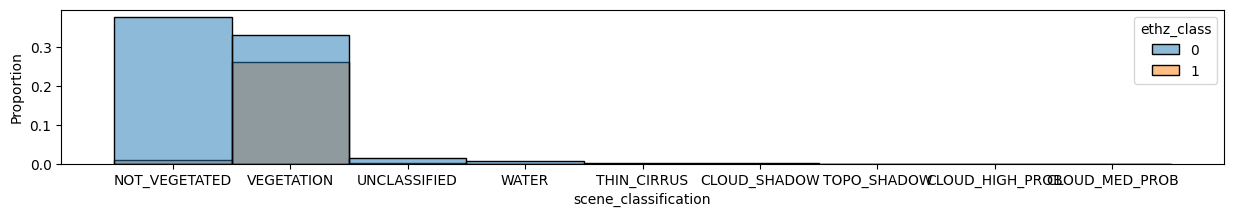

In [56]:
# There are points that are not vegetated, BUT considered as "cocoa" 
plt.figure(figsize=(15,2))
sns.histplot(x="scene_classification", hue='ethz_class', data=df, stat="proportion")

In [57]:
# Ditch defective points
mask = df.scene_classification == "NO_DATA"
mask |= df.scene_classification == "DEFECTIVE_PX"
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]
df.head(1)

Discarded 0/10000 (0.00%) points


,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,ethz_class
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0,0,0,0,0,0,NOT_VEGETATED,6,0.005342,0


In [58]:
# Ditch clouds
mask = df.scene_classification == "CLOUD_MED_PROB"
mask |= df.scene_classification == "CLOUD_HIGH_PROB"
mask |= df.scene_classification == "THIN_CIRRUS"
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]
df.head(1)

Discarded 8/10000 (0.08%) points


,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,ethz_class
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0,0,0,0,0,0,NOT_VEGETATED,6,0.005342,0


In [59]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)

train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 11:10:18,408] A new study created in memory with name: no-name-d174e18c-32a9-4c97-8484-3ef6608e5827


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 11:10:20,137] Trial 0 finished with value: 0.7683534907138085 and parameters: {'n_estimators': 489, 'learning_rate': 0.12876710477151623, 'max_depth': 5, 'num_leaves': 111, 'subsample': 0.7164891617254978, 'colsample_bytree': 0.8335119173002858, 'min_child_samples': 47}. Best is trial 0 with value: 0.7683534907138085.
[I 2026-06-17 11:10:26,066] Trial 1 finished with value: 0.7493074720075199 and parameters: {'n_estimators': 259, 'learning_rate': 0.180590240989701, 'max_depth': 12, 'num_leaves': 143, 'subsample': 0.9627255346828303, 'colsample_bytree': 0.6604559223156895, 'min_child_samples': 12}. Best is trial 0 with value: 0.7683534907138085.
[I 2026-06-17 11:10:27,865] Trial 2 finished with value: 0.7666687611983442 and parameters: {'n_estimators': 460, 'learning_rate': 0.01202302452558084, 'max_depth': 5, 'num_leaves': 107, 'subsample': 0.5882239070429718, 'colsample_bytree': 0.871023246695679, 'min_child_samples': 82}. Best is trial 0 with value: 0.7683534907138085.


# Add TCI

In [60]:
# Add TCI
df["tci"] = 1.2 * (df["rededge"] - df["green"]) - 1.5 * (df["red"] - df["green"]) * np.sqrt(df["rededge"] / df["red"])

In [61]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] + ["tci"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)
X_train.head(2)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,tci
1033625,0.031373,0.047059,0.047059,0.121569,0.137255,0.160784,0.137255,0.156863,0.152941,0.101961,0.089412
1506213,0.039216,0.058824,0.050980,0.141176,0.149020,0.168627,0.145098,0.168627,0.152941,0.094118,0.118401


In [62]:
train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 11:10:36,704] A new study created in memory with name: no-name-78d0db3d-7287-48d3-b12c-d65662291516


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 11:10:40,962] Trial 0 finished with value: 0.7504666230164391 and parameters: {'n_estimators': 388, 'learning_rate': 0.1423814011225078, 'max_depth': 12, 'num_leaves': 133, 'subsample': 0.9861096806952998, 'colsample_bytree': 0.8087943452905375, 'min_child_samples': 47}. Best is trial 0 with value: 0.7504666230164391.
[I 2026-06-17 11:10:43,570] Trial 1 finished with value: 0.7729173845187058 and parameters: {'n_estimators': 383, 'learning_rate': 0.044178296087422395, 'max_depth': 6, 'num_leaves': 39, 'subsample': 0.7333454184569558, 'colsample_bytree': 0.5345720481570714, 'min_child_samples': 18}. Best is trial 1 with value: 0.7729173845187058.
[I 2026-06-17 11:10:44,208] Trial 2 finished with value: 0.7656968180912601 and parameters: {'n_estimators': 246, 'learning_rate': 0.020375836223780294, 'max_depth': 3, 'num_leaves': 247, 'subsample': 0.5336090244691063, 'colsample_bytree': 0.9875365321494158, 'min_child_samples': 85}. Best is trial 1 with value: 0.772917384518705

# Add NDVI

In [63]:
# Add NDVI
df["ndvi"] = (df["nir"] - df["red"]) / (df["nir"] + df["red"])
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,ethz_class,tci,ndvi
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0,0,0,0,NOT_VEGETATED,6,0.005342,0,0.094118,0.454545


In [70]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] + ["tci", "ndvi"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)
X_train.head(2)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,tci,ndvi
1033625,0.031373,0.047059,0.047059,0.121569,0.137255,0.160784,0.137255,0.156863,0.152941,0.101961,0.089412,0.489362
1506213,0.039216,0.058824,0.050980,0.141176,0.149020,0.168627,0.145098,0.168627,0.152941,0.094118,0.118401,0.480000


In [71]:
clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 11:16:01,804] A new study created in memory with name: no-name-44857db4-9762-4a4b-ba1f-45fd9035b658


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 11:16:02,966] Trial 0 finished with value: 0.7699496372428385 and parameters: {'n_estimators': 318, 'learning_rate': 0.048736958919896725, 'max_depth': 5, 'num_leaves': 145, 'subsample': 0.9965069136477336, 'colsample_bytree': 0.5534076083837498, 'min_child_samples': 60}. Best is trial 0 with value: 0.7699496372428385.
[I 2026-06-17 11:16:04,831] Trial 1 finished with value: 0.7696418522757285 and parameters: {'n_estimators': 448, 'learning_rate': 0.0465857336163522, 'max_depth': 9, 'num_leaves': 19, 'subsample': 0.8594303935416447, 'colsample_bytree': 0.9633112513001547, 'min_child_samples': 72}. Best is trial 0 with value: 0.7699496372428385.
[I 2026-06-17 11:16:09,220] Trial 2 finished with value: 0.7664587392091594 and parameters: {'n_estimators': 214, 'learning_rate': 0.015727626444149115, 'max_depth': 14, 'num_leaves': 117, 'subsample': 0.5678252702875024, 'colsample_bytree': 0.7935133769259621, 'min_child_samples': 35}. Best is trial 0 with value: 0.769949637242838

# Add GNDVI, NDWI, and others

In [95]:
# https://clearsky.vision/knowledge/sentinel2-indices-cheatsheet

def compute_tci(df, suffix):
    return 1.2 * (df[f"rededge{suffix}"] - df[f"green{suffix}"]) - 1.5 * (df[f"red{suffix}"] - df[f"green{suffix}"]) * np.sqrt(df[f"rededge{suffix}"] / df[f"red{suffix}"])

def compute_ndvi(df, suffix):
    return (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + df[f"red{suffix}"])

def compute_evi(df, suffix):
    G, C1, C2, L = 2.5, 6, 7.5, 1.0
    return G * (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + C1 * df[f"red{suffix}"] + C2 * df[f"blue{suffix}"] + L)

def compute_evi2(df, suffix):
    return (df[f"nir{suffix}"] - df[f"swir11{suffix}"]) / (df[f"nir{suffix}"] + df[f"swir11{suffix}"])

def compute_ndre_b5(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"rededge{suffix}"]) / (df[f"B8A{suffix}"] + df[f"rededge{suffix}"])

def compute_ndre_b6(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"B06{suffix}"]) / (df[f"B8A{suffix}"] + df[f"B06{suffix}"])

def compute_ndre_b7(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"B07{suffix}"]) / (df[f"B8A{suffix}"] + df[f"B07{suffix}"])

def compute_gndvi(df, suffix):
    return 2.5 * (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + 2.4 * df[f"red{suffix}"] + 1) 

def compute_ndwi(df, suffix):
    return (df[f"nir{suffix}"] - df[f"swir11{suffix}"]) / (df[f"nir{suffix}"] + df[f"swir11{suffix}"])
    
df["evi2"] = compute_evi2(df, '')
df["evi"] = compute_evi(df, '')
df["ndre_b5"] = compute_ndre_b5(df, '')
df["ndre_b6"] = compute_ndre_b6(df, '')
df["ndre_b7"] = compute_ndre_b7(df, '')
df["gndvi"] = compute_gndvi(df, '')
df["ndwi"] = compute_ndwi(df, '')
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,ndre_b5__3x3_var,evi2__5x5_median,ndre_b7__5x5_median,ndre_b6__5x5_median,ndre_b5__5x5_median,evi2__5x5_var,ndre_b7__5x5_var,ndre_b6__5x5_var,ndre_b5__5x5_var,evi
97343,-2.069206,7.434594,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,...,0.8,-0.123288,-0.013333,0.057143,0.072464,-0.411765,-0.066667,0.166667,0.555556,0.119332


In [97]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] + ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)


clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 11:36:00,870] A new study created in memory with name: no-name-35a58525-e614-4f65-b25e-55bf2096f23a


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 11:36:01,297] Trial 0 finished with value: 0.7795247536227248 and parameters: {'n_estimators': 124, 'learning_rate': 0.17646812733637313, 'max_depth': 4, 'num_leaves': 112, 'subsample': 0.6912540866401073, 'colsample_bytree': 0.7800310814303051, 'min_child_samples': 89}. Best is trial 0 with value: 0.7795247536227248.
[I 2026-06-17 11:36:03,204] Trial 1 finished with value: 0.7717623709815916 and parameters: {'n_estimators': 121, 'learning_rate': 0.020023631791472936, 'max_depth': 14, 'num_leaves': 54, 'subsample': 0.6452436596647254, 'colsample_bytree': 0.7247533985766642, 'min_child_samples': 30}. Best is trial 0 with value: 0.7795247536227248.
[I 2026-06-17 11:36:06,529] Trial 2 finished with value: 0.7665320726163756 and parameters: {'n_estimators': 407, 'learning_rate': 0.08039792083545498, 'max_depth': 9, 'num_leaves': 201, 'subsample': 0.6057366821338497, 'colsample_bytree': 0.8542176397807225, 'min_child_samples': 94}. Best is trial 0 with value: 0.779524753622724

# Take into account #valid pixels

In [98]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] 
features += ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]
features += ['valid_observations']
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)


clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 11:36:16,663] A new study created in memory with name: no-name-8439375d-51c1-4c02-a965-5857212b1b1d


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 11:36:17,268] Trial 0 finished with value: 0.7740415361695191 and parameters: {'n_estimators': 464, 'learning_rate': 0.013724872502814378, 'max_depth': 2, 'num_leaves': 56, 'subsample': 0.5140493820952643, 'colsample_bytree': 0.5935470540963509, 'min_child_samples': 70}. Best is trial 0 with value: 0.7740415361695191.
[I 2026-06-17 11:36:18,919] Trial 1 finished with value: 0.7819768434693606 and parameters: {'n_estimators': 196, 'learning_rate': 0.015759097194167914, 'max_depth': 7, 'num_leaves': 90, 'subsample': 0.6715024946138016, 'colsample_bytree': 0.6668288974006401, 'min_child_samples': 76}. Best is trial 1 with value: 0.7819768434693606.
[I 2026-06-17 11:36:20,499] Trial 2 finished with value: 0.7783096539568153 and parameters: {'n_estimators': 311, 'learning_rate': 0.12897543284103707, 'max_depth': 6, 'num_leaves': 57, 'subsample': 0.7792397472128535, 'colsample_bytree': 0.7552775118910775, 'min_child_samples': 92}. Best is trial 1 with value: 0.7819768434693606.

# Use neighbouring pixel values

In [101]:
for suffix in ['_3x3_median', '_3x3_var', "_5x5_median", "_5x5_var"]:
    df[f"tci_{suffix}"] = compute_tci(df, suffix)
    df[f"ndvi_{suffix}"] = compute_ndvi(df, suffix)
    df[f"evi_{suffix}"] = compute_evi(df, suffix)
    df[f"evi2_{suffix}"] = compute_evi2(df, suffix)
    df[f"ndre_b7_{suffix}"] = compute_ndre_b7(df, suffix)
    df[f"ndre_b6_{suffix}"] = compute_ndre_b6(df, suffix)
    df[f"ndre_b5_{suffix}"] = compute_ndre_b5(df, suffix)
    df[f"gndvi_{suffix}"] = compute_gndvi(df, suffix)
    df[f"ndwi_{suffix}"] = compute_ndwi(df, suffix)

neighbor_cols = [e for e in df.columns if e.endswith(("_min", '_max', "_median", '_var'))]

df[neighbor_cols].head(1)

,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,green_3x3_median,green_3x3_min,...,ndre_b6__5x5_median,ndre_b5__5x5_median,evi2__5x5_var,ndre_b7__5x5_var,ndre_b6__5x5_var,ndre_b5__5x5_var,evi__3x3_median,evi__3x3_var,evi__5x5_median,evi__5x5_var
97343,0.047059,0.039216,0.062745,0.007843,0.047059,0.039216,0.062745,0.007843,0.043137,0.043137,...,0.057143,0.072464,-0.411765,-0.066667,0.166667,0.555556,0.119332,0.04562,0.119332,0.027574


In [103]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] 
features += ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]
features += ['valid_observations']
features += neighbor_cols
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)


clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test, n_trials=10);

[I 2026-06-17 11:37:12,566] A new study created in memory with name: no-name-a590d0c0-5a28-4317-a439-b14bdec828d5


Starting Optuna hyperparameter optimization...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-17 11:37:20,901] Trial 0 finished with value: 0.8306852332368205 and parameters: {'n_estimators': 395, 'learning_rate': 0.020221506814359552, 'max_depth': 8, 'num_leaves': 187, 'subsample': 0.5416454295207822, 'colsample_bytree': 0.9846193485422392, 'min_child_samples': 61}. Best is trial 0 with value: 0.8306852332368205.
[I 2026-06-17 11:37:26,852] Trial 1 finished with value: 0.8259010790390576 and parameters: {'n_estimators': 459, 'learning_rate': 0.06524354946708606, 'max_depth': 5, 'num_leaves': 222, 'subsample': 0.5573896736694062, 'colsample_bytree': 0.6690893081948233, 'min_child_samples': 60}. Best is trial 0 with value: 0.8306852332368205.
[I 2026-06-17 11:37:28,405] Trial 2 finished with value: 0.8276253553765326 and parameters: {'n_estimators': 286, 'learning_rate': 0.08929823321810233, 'max_depth': 2, 'num_leaves': 179, 'subsample': 0.9142049241457012, 'colsample_bytree': 0.9474273145827503, 'min_child_samples': 55}. Best is trial 0 with value: 0.830685233236820

In [106]:
# Dump to disk
import joblib

payload = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test,
    'clf': clf,
}

joblib.dump(payload, 'trained.joblib')

['trained.joblib']

# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?